In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import sys
from pathlib import Path

# Go to project root (REALTIMEFRAUDDETECTION)
project_root = Path().resolve().parent
sys.path.append(str(project_root))

In [4]:
df=pd.read_csv("../data/dataset_PFE_CDM_complet.csv")
df.shape

(1100000, 17)

In [5]:
df['Time']=pd.to_datetime(df['Time'])
df['Age']=df['Age'].astype(int)

df['Hour']=df['Time'].dt.hour
df['Date']=df['Time'].dt.date

In [6]:
df.sort_values(['Account Number','Time'],inplace=True)
df['rank']=df.groupby("Account Number")['Time'].rank(method='first',pct=True)

# Feature Engineering

In [7]:
from src.features.TimeFeatures import ComputeTimeFeatures
from src.features.CatEntropy import ComputeCatEntropy
from src.features.CatFreq import ComputeCatFreq
from src.preprocessing.TrainTestSplit import split

In [8]:
df=ComputeTimeFeatures(df)
df=ComputeCatEntropy(df)
df=ComputeCatFreq(df)

In [9]:
df=df[['Age','rank',
       'LogAmount', 'MovingAvg','MovingStd', 'LogTimeDiff','Hour',
       'TransactionTypeEntropy', 'ChannelEntropy','CardTypeEntropy', 'MerchandEntropy', 'CountryEntropy', 'CityEntropy',
       'TransactionTypeFreq','ChannelFreq','CardTypeFreq', 'MerchandFreq', 'CountryFreq','CityFreq']]

traindf,testdf=split(df)

In [10]:
traindf.shape

(879198, 18)

# Isolation Forest

In [11]:
from src.models.IsolationForest import IsolationForestModel
from src.training.train import trainmodel

2026-03-11 11:41:12.053681: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-11 11:41:12.531205: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-11 11:41:14.297246: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [12]:
stdiso=IsolationForestModel(nestimators=244,maxsamples=0.64,contamination=0.05)
meaniso=IsolationForestModel(nestimators=111,maxsamples=0.62,contamination=0.01)
skewiso=IsolationForestModel(nestimators=190,maxsamples=0.53,contamination=0.04)

trainmodel(stdiso,traindf,runname='testIF')
trainmodel(meaniso,traindf,runname='testIF')
trainmodel(skewiso,traindf,runname='testIF')

{'score_mean': -0.08089585771218295,
 'score_std': 0.03641369562695906,
 'score_skew': 2.1029776095383035,
 'score_p95': -0.008367777744890682,
 'score_p99': 0.061534159168549776,
 'tailsep': 0.14243001688073273}

In [13]:
def ComputeAvgPathLength(model, X):
    depths = []

    for tree in model.estimators_:
        node_indicator = tree.decision_path(X)
        depth = node_indicator.sum(axis=1)
        depths.append(np.array(depth).reshape(-1))

    depths = np.array(depths)
    return depths.mean(axis=0)

# AutoEncoder

In [14]:
from src.models.AutoEncoder import AutoEncoderModel

In [ ]:
inputdim=traindf.shape[1]

meanae=AutoEncoderModel(inputdim=inputdim,epochs=10,latentdim=20,lr=0.0003,batchsize=64)
stdae=AutoEncoderModel(inputdim=inputdim,epochs=10,latentdim=6,lr=0.0005,batchsize=256)
skewae=AutoEncoderModel(inputdim=inputdim,epochs=10,latentdim=4,lr=0.001,batchsize=256)

trainmodel(meanae,traindf,runname='testAE')
trainmodel(stdae,traindf,runname='testAE')
trainmodel(skewae,traindf,runname='testAE')

Epoch 1/10
12364/12364 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - loss: 0.5567 - val_loss: 0.0032
Epoch 2/10
12364/12364 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - loss: 0.0011 - val_loss: 7.7326e-04
Epoch 3/10
12364/12364 ━━━━━━━━━━━━━━━━━━━━ 27s 2ms/step - loss: 7.3969e-04 - val_loss: 6.8865e-04
Epoch 4/10
12364/12364 ━━━━━━━━━━━━━━━━━━━━ 27s 2ms/step - loss: 6.6989e-04 - val_loss: 4.7498e-04
Epoch 5/10
12364/12364 ━━━━━━━━━━━━━━━━━━━━ 28s 2ms/step - loss: 6.0637e-04 - val_loss: 5.5150e-04
Epoch 6/10
12364/12364 ━━━━━━━━━━━━━━━━━━━━ 28s 2ms/step - loss: 5.5735e-04 - val_loss: 5.1440e-04
Epoch 7/10
12364/12364 ━━━━━━━━━━━━━━━━━━━━ 28s 2ms/step - loss: 5.1716e-04 - val_loss: 3.2781e-04
Epoch 8/10
12364/12364 ━━━━━━━━━━━━━━━━━━━━ 28s 2ms/step - loss: 4.7656e-04 - val_loss: 3.8360e-04
Epoch 9/10
12364/12364 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - loss: 4.4718e-04 - val_loss: 4.8548e-04
Epoch 10/10
12364/12364 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - loss: 4.2068e-04 - val_loss: 3.2234e-04
27475/27475 ━━━━━━━━━

{'score_mean': 0.0002730158536544724,
 'score_std': 0.0012321553752342037,
 'score_skew': 60.39850554234676,
 'score_p95': 0.0005289240414834616,
 'score_p99': 0.002155064406304322,
 'tailsep': 0.0018820485526498498}

# SelfOrganizingMap

In [16]:
from src.models.SelfOrganizingMap import SOMModel

In [17]:
stdsom=SOMModel(inputlen=inputdim,x=6,y=9,sigma=1.05,learning_rate=0.5,iterations=764)
meansom=SOMModel(inputlen=inputdim,x=19,y=16,sigma=0.87,learning_rate=0.24,iterations=755)
skewsom=SOMModel(inputlen=inputdim,x=16,y=17,sigma=1.6,learning_rate=0.21,iterations=2564)

trainmodel(stdsom,traindf,runname='testSOM')
trainmodel(meansom,traindf,runname='testSOM')
trainmodel(skewsom,traindf,runname='testSOM')

{'score_mean': 3.383021675084163,
 'score_std': 2.1216897010241955,
 'score_skew': 1.4727715182402539,
 'score_p95': 8.21756586459661,
 'score_p99': 10.217056319410007,
 'tailsep': 6.834034644325844}

# Results Exploration

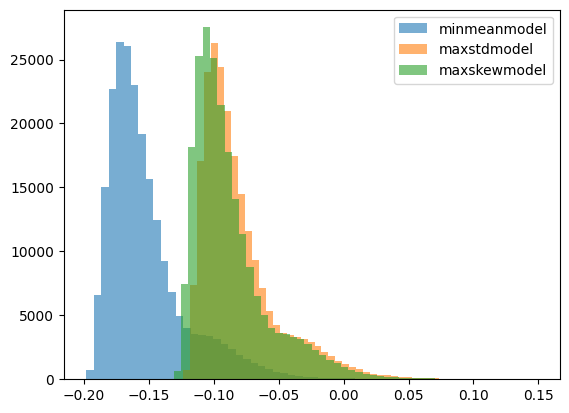

In [ ]:
 scores=meaniso.score(testdf)
plt.hist(scores,bins=50,label='minmeanmodel',alpha=0.6)
scores=stdiso.score(testdf)
plt.hist(scores,bins=50,label='maxstdmodel',alpha=0.6)
scores=skewiso.score(testdf)
plt.hist(scores,bins=50,label='maxskewmodel',alpha=0.6)
plt.legend()
plt.show()

6901/6901 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
6901/6901 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step


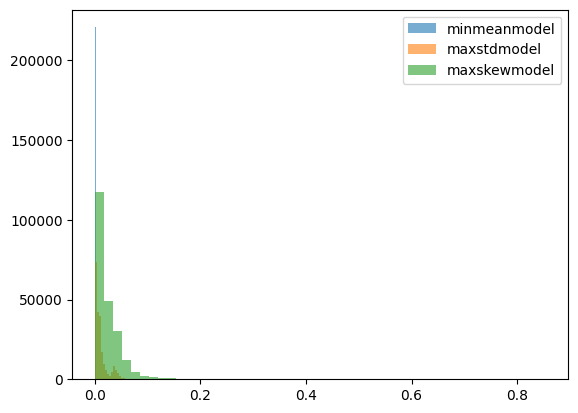

In [ ]:
scores=meanae.score(testdf)
plt.hist(scores,bins=50,label='minmeanmodel',alpha=0.6)
scores=stdae.score(testdf)
plt.hist(scores,bins=50,label='maxstdmodel',alpha=0.6)
scores=skewae.score(testdf)
plt.hist(scores,bins=50,label='maxskewmodel',alpha=0.6)
plt.legend()
plt.show()

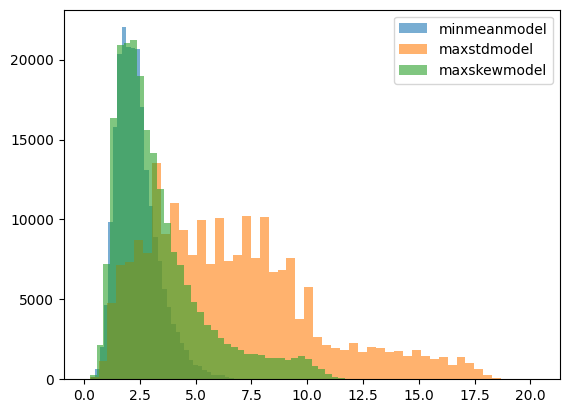

In [20]:
scores=meansom.score(testdf)
plt.hist(scores,bins=50,label='minmeanmodel',alpha=0.6)
scores=stdsom.score(testdf)
plt.hist(scores,bins=50,label='maxstdmodel',alpha=0.6)
scores=skewsom.score(testdf)
plt.hist(scores,bins=50,label='maxskewmodel',alpha=0.6)
plt.legend()
plt.show()